# Pre-processing: WorldPop population data

Download age- and sex-disaggregated WorldPop rasters and aggregate them into a population netCDF with a labelled `group` dimension (`children`, `adults`, `total`), clipped to an area of interest.

> The flood-depth input is created separately in `0_dummy_flood_map_creation.ipynb`. No alignment step is needed here — the model reprojects and clips every input onto a common grid automatically at run time (see `4_run_model.ipynb`).

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from d_health import get_population_data
from d_health.io import load_population

c:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\.pixi\envs\default\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 2. Configure the run

Pick the country (ISO3) and year, define the area of interest, and choose an output directory. Here we use a hand-set bounding box around **Paramaribo** (Suriname's capital) instead of an external flood map. WorldPop downloads will be clipped to those bounds — only the cells inside Paramaribo are kept; the rest are never written to disk.

In [2]:
country = "SUR"   # Suriname
year = 2020
output_dir = Path("./data")
population_path = output_dir / f"{country.lower()}_population_{year}_combined.nc"

# Paramaribo bounding box in EPSG:4326 (xmin, ymin, xmax, ymax)
paramaribo_bounds = (-55.27, 5.78, -55.10, 5.93)

## 3. Fetch and aggregate (clipped to Paramaribo)

Pass the bounding box as the `clip` argument. `get_population_data` downloads each per-age raster into a temp directory, masks it to the clip bounds, sums in memory, and writes only the final netCDF to `population_path`. The raw per-age files are deleted as they're consumed — nothing persists outside that one file.

Groups written along the `group` dimension: `children`, `adults`, `total` (with descriptive `children_0_9` / `adults_10_plus` labels kept in `long_name`).

In [3]:
raster_path = get_population_data(
    country, year, population_path,
    clip=paramaribo_bounds,
)
raster_path

d_health.preprocessing.population | INFO | Fetching WorldPop SUR 2020 (Global_2000_2020_Constrained, constrained) — 36 files, clip=yes
d_health.preprocessing.population | INFO | Downloading child rasters (6 files: 3 age bins × 2 sexes)
d_health.preprocessing.population | INFO | Aggregated child: (181, 205), sum=43573
d_health.preprocessing.population | INFO | Downloading adult rasters (30 files: 15 age bins × 2 sexes)
d_health.preprocessing.population | INFO | Aggregated adult: (181, 205), sum=237297
d_health.io | INFO | Wrote sur_population_2020_combined.nc (1 variable(s))
d_health.preprocessing.population | INFO | Wrote data\sur_population_2020_combined.nc (0.2 MB)


WindowsPath('data/sur_population_2020_combined.nc')

## 4. Inspect the output

Sanity-check: a `group` dimension with the right labels, and `total ≈ children + adults`.

In [4]:
pop = load_population(raster_path)
print("CRS:         ", pop.rio.crs)
print("Shape:       ", dict(pop.sizes))
print("Groups:      ", list(map(str, pop["group"].values)))

children = pop.sel(group="children").values
adults = pop.sel(group="adults").values
total = pop.sel(group="total").values

print(f"\nChildren (0-9):  {children.sum():>14,.0f}")
print(f"Adults (10+):    {adults.sum():>14,.0f}")
print(f"Total:           {total.sum():>14,.0f}")

np.testing.assert_allclose(total, children + adults, rtol=1e-5)
print("\nIdentity check passed: total == children + adults")

CRS:          EPSG:4326
Shape:        {'group': 3, 'y': 181, 'x': 205}
Groups:       ['children', 'adults', 'total']

Children (0-9):          43,573
Adults (10+):           237,297
Total:                  280,870

Identity check passed: total == children + adults


## 5. Visualise

Quick log-scaled view of each band, side-by-side.

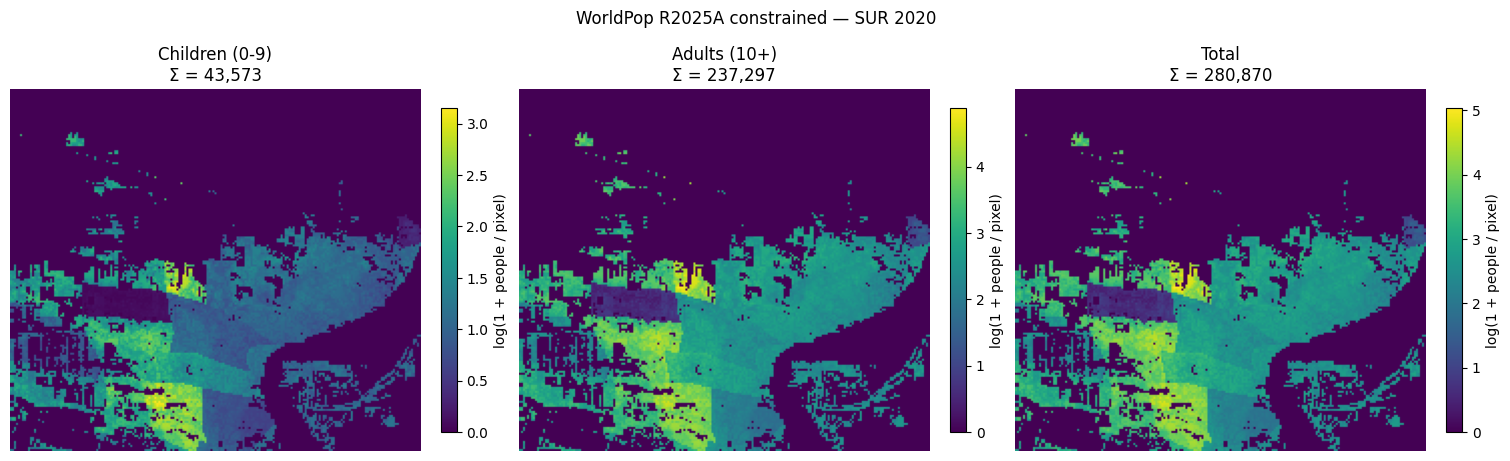

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, band, title in zip(axes, (children, adults, total),
                            ("Children (0-9)", "Adults (10+)", "Total")):
    img = ax.imshow(np.log1p(band), cmap="viridis")
    ax.set_title(f"{title}\nΣ = {band.sum():,.0f}")
    ax.set_axis_off()
    fig.colorbar(img, ax=ax, shrink=0.7, label="log(1 + people / pixel)")
fig.suptitle(f"WorldPop R2025A constrained — {country} {year}")
plt.show()